# Compare Chunking Outputs Notebook


- `cleaned_source`: cleaned extracted pdf text (before any chunking)
- `semantic_raw`: Typescript chunker output before postprocessing
- `semantic_ts`: final postprocessed Typescript chunks intended for RAG
- `python_legacy`: legacy python pipeline


In [10]:
#Imports
from __future__ import annotations
import json
import re
import shutil
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path('/Users/matthewplambeck/Desktop/Deployable-Knowledge')
BASE_DIR = REPO_ROOT / 'outputs-test'
SOURCE_PDF = REPO_ROOT / 'documents/17-13-tactical-casualty-combat-care-handbook-v5-may-17-distro-a.pdf'
NODE_BIN = Path('/opt/homebrew/bin/node')

FILES = {
    'semantic_ts': BASE_DIR / 'chunker-semantic.json',
    'semantic_raw': BASE_DIR / 'chunker-semantic-raw.json',
    'python_legacy': BASE_DIR / 'chunker-python.json',}


def add_counts(frame: pd.DataFrame) -> pd.DataFrame:
    counted = frame.copy()
    counted['wordCount'] = counted['content'].str.split().str.len()
    counted['sentenceCountApprox'] = (
        counted['content']
        .str.replace('', ' ', regex=False)
        .str.split('.')
        .apply(lambda parts: sum(1 for part in parts if part.strip()))
    )
    return counted[['source_name', 'model', 'pageIndex', 'chunkIndex', 'chunkId', 'wordCount', 'sentenceCountApprox', 'content']]


def load_chunks(path: Path, source_name: str) -> pd.DataFrame:
    payload = json.loads(path.read_text())
    rows = payload['chunks'] if isinstance(payload, dict) and 'chunks' in payload else payload
    frame = pd.DataFrame(rows).copy()
    frame['source_name'] = source_name
    frame['model'] = payload.get('model', source_name) if isinstance(payload, dict) else source_name
    return add_counts(frame)


def load_cleaned_source_frame(pdf_path: Path) -> pd.DataFrame:

    node_script = f"""
const {{ TextExtract }} = await import('./src/lib/server/providers/parse_pipeline/text-extract.ts');
const {{ cleanPageText, stripInlineTables }} = await import('./src/lib/server/providers/parse_pipeline/chunker-semantic.ts');
const source = {{
  title: {json.dumps(pdf_path.name)},
  type: 'PDF',
  path: {json.dumps(str(pdf_path))},
}};
const pages = await TextExtract(source);
const rows = pages
  .filter((page) => page.chunkType === 'TEXT')
  .map((page) => {{
    const content = stripInlineTables(cleanPageText(page.content));
    return {{
      source_name: 'cleaned_source',
      model: 'cleaned_source',
      pageIndex: Number(page.pageIndex),
      chunkIndex: 0,
      chunkId: `source-${{page.pageIndex}}`,
      content,
    }};}})
  .filter((row) => row.content);
console.log(JSON.stringify(rows));
"""
    result = subprocess.run(
        [str(NODE_BIN), '--import', 'tsx/esm', '-e', node_script],
        cwd=REPO_ROOT,
        check=True,
        capture_output=True,
        text=True)
    frame = pd.DataFrame(json.loads(result.stdout)).copy()
    return add_counts(frame)


def load_available_frames() -> tuple[dict[str, pd.DataFrame], pd.DataFrame]:
    frames: dict[str, pd.DataFrame] = {}
    status_rows: list[dict[str, str]] = []

    for name, path in FILES.items():
        exists = path.exists()
        status_rows.append({
            'source_name': name,
            'path': str(path),})

        if exists:
            frames[name] = load_chunks(path, name)
        else:
            print(f'Missing chunk output for notebook comparison: {path}')

    if SOURCE_PDF.exists():
        status_rows.append({
            'source_name': 'cleaned_source',
            'path': str(SOURCE_PDF),
        })

    return frames, pd.DataFrame(status_rows)


frames, file_status = load_available_frames()
source_frame = load_cleaned_source_frame(SOURCE_PDF) if SOURCE_PDF.exists() else pd.DataFrame()
file_status #Check to ensure four files loaded

,source_name,path
0,semantic_ts,/Users/matthewplambeck/Desktop/Deployable-Know...
1,semantic_raw,/Users/matthewplambeck/Desktop/Deployable-Know...
2,python_legacy,/Users/matthewplambeck/Desktop/Deployable-Know...
3,cleaned_source,/Users/matthewplambeck/Desktop/Deployable-Know...


In [11]:
#Quick summary
summary_counts = pd.DataFrame({
    name: {
        'chunks': len(frame),
        'pages_with_chunks': frame['pageIndex'].nunique(),
        'mean_words': round(frame['wordCount'].mean(), 2),
        'median_words': frame['wordCount'].median(),
        'max_words': frame['wordCount'].max(),
        'mean_sentences': round(frame['sentenceCountApprox'].mean(), 2),
        'median_sentences': frame['sentenceCountApprox'].median(),
        'max_sentences': frame['sentenceCountApprox'].max(),
    }
    for name, frame in frames.items()
}).T if frames else pd.DataFrame()
summary_counts

,chunks,pages_with_chunks,mean_words,median_words,max_words,mean_sentences,median_sentences,max_sentences
semantic_ts,218.0,114.0,110.69,119.0,200.0,8.42,8.0,21.0
semantic_raw,218.0,121.0,108.03,117.5,200.0,8.19,8.0,21.0
python_legacy,350.0,121.0,48.59,32.0,282.0,3.59,2.0,22.0


In [12]:
# Chunk-size distribution by implementation
if frames:
    distribution = (
        pd.concat(frames.values(), ignore_index=True)
        .groupby(['source_name', 'sentenceCountApprox'])
        .size()
        .rename('chunkCount')
        .reset_index()
        .pivot(index='sentenceCountApprox', columns='source_name', values='chunkCount')
        .fillna(0)
        .astype(int)
    )
else:
    distribution = pd.DataFrame()

distribution

source_name,python_legacy,semantic_raw,semantic_ts
sentenceCountApprox,,,
1,115,8,1
2,74,18,17
3,47,7,9
4,27,6,6
5,28,21,23
6,11,13,14
7,5,23,23
8,9,18,18
9,6,24,25


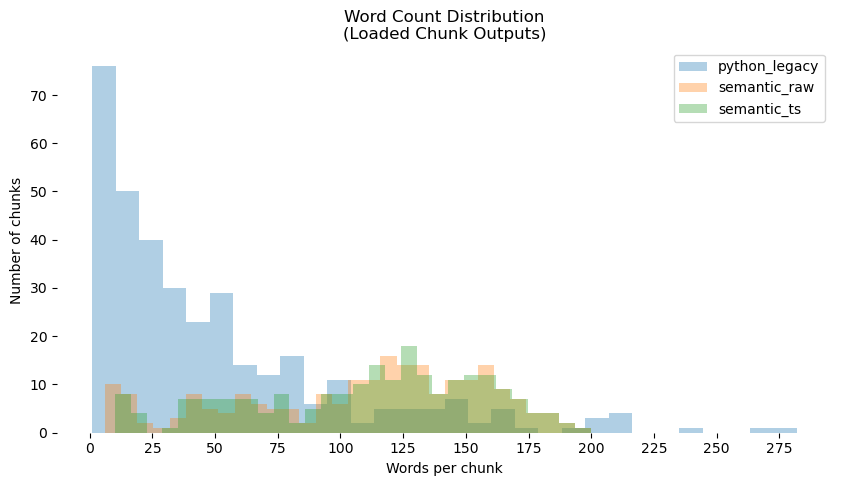

In [13]:
#Word Count Histogram (Same data as above but at the word level now ^)
plot_frame = pd.concat(frames.values(), ignore_index=True)
plt.figure(figsize=(10, 5))
for source_name, group in plot_frame.groupby("source_name"):
    plt.hist(group["wordCount"], bins=30, alpha=0.35, label=source_name)
plt.xlabel("Words per chunk")
plt.xticks(np.arange(0,300, 25))
plt.ylabel("Number of chunks")
plt.title("Word Count Distribution\n(Loaded Chunk Outputs)")
for spine in plt.gca().spines.values():
    spine.set_visible(False)
plt.legend()
plt.show()


## Source Coverage Check

Compare cleaned extracted pdf text against `semantic_raw` and `semantic_ts`. Used to determine if chunking pre and post processing is loosing any meaningful text from the pdf


In [14]:
#Helper Python Functions
def normalize_text(text: str) -> str:
    return re.sub(r'\s+', ' ', text).strip()

def split_sentence_like(text: str) -> list[str]:
    normalized = normalize_text(text)
    if not normalized:
        return []
    parts = re.split(r'(?<=[.!?])\s+', normalized)
    return [part.strip() for part in parts if part.strip()]

def tokenize_words(text: str) -> list[str]:
    return re.findall(r"[A-Za-z0-9']+", text.lower())

def collect_sentence_set(frame: pd.DataFrame) -> set[str]:
    sentences = set()
    for content in frame['content']:
        sentences.update(split_sentence_like(content))
    return sentences

def collect_word_set(frame: pd.DataFrame) -> set[str]:
    words = set()
    for content in frame['content']:
        words.update(tokenize_words(content))
    return words

def collect_page_set(frame: pd.DataFrame) -> set[int]:
    return {int(page) for page in frame['pageIndex'].dropna().tolist()}

source_sentences = collect_sentence_set(source_frame)
source_words = collect_word_set(source_frame)
source_pages = collect_page_set(source_frame)
source_coverage_rows = []
for source_name in ['semantic_raw', 'semantic_ts']:
    frame = frames.get(source_name)
    if frame is None:
        continue

    sentences = collect_sentence_set(frame)
    words = collect_word_set(frame)
    source_coverage_rows.extend([
        {
            'source_name': source_name,
            'metric': 'sentences',
            'source_unique_count': len(source_sentences),
            'chunk_unique_count': len(sentences),
            'missing_unique_from_chunks': len(source_sentences - sentences),
            'extra_unique_in_chunks': len(sentences - source_sentences),
            'source_recall_pct': round(100 * len(source_sentences & sentences) / max(len(source_sentences), 1), 2),
        },
        {
            'source_name': source_name,
            'metric': 'words',
            'source_unique_count': len(source_words),
            'chunk_unique_count': len(words),
            'missing_unique_from_chunks': len(source_words - words),
            'extra_unique_in_chunks': len(words - source_words),
            'source_recall_pct': round(100 * len(source_words & words) / max(len(source_words), 1), 2),
        },
    ])

source_coverage_summary = pd.DataFrame(source_coverage_rows)
source_coverage_summary

# source_unique_count: number of unique normalized items in cleaned_source
# chunk_unique_count: number of unique normalized items found in the chunk output being tested
# missing_unique_from_chunks: items present in cleaned_source but not found in the chunks
# extra_unique_in_chunks: items present in the chunks but not in cleaned_source. For semantic_ts (sentences) added is likely tables and 
# source_recall_pct: percent of source items recovered by the chunks

#With 'items' being eiter unique sentences or words

,source_name,metric,source_unique_count,chunk_unique_count,missing_unique_from_chunks,extra_unique_in_chunks,source_recall_pct
0,semantic_raw,sentences,1336,1361,1,26,99.93
1,semantic_raw,words,3236,3236,0,0,100.00
2,semantic_ts,sentences,1336,1381,10,55,99.25
3,semantic_ts,words,3236,3387,0,151,100.00


In [6]:
page_coverage_rows = []
missing_page_samples: dict[str, pd.Series] = {}
missing_sentence_samples: dict[str, pd.Series] = {}
missing_word_samples: dict[str, pd.Series] = {}

for source_name in ['semantic_raw', 'semantic_ts']:
    frame = frames.get(source_name)
    if frame is None:
        continue

    pages = collect_page_set(frame)
    sentences = collect_sentence_set(frame)
    words = collect_word_set(frame)
    missing_pages = sorted(source_pages - pages)

    page_coverage_rows.append({
        'source_name': source_name,
        'source_pages': len(source_pages),
        'pages_with_chunks': len(pages),
        'missing_page_count': len(missing_pages),
    })
    missing_page_samples[f'missing_pages_from_{source_name}'] = pd.Series(missing_pages[:20])
    missing_sentence_samples[f'missing_sentences_from_{source_name}'] = pd.Series(sorted(source_sentences - sentences)[:20])
    missing_word_samples[f'missing_words_from_{source_name}'] = pd.Series(sorted(source_words - words)[:30])

page_coverage_summary = pd.DataFrame(page_coverage_rows)

display(source_coverage_summary)
display(page_coverage_summary)
display(pd.DataFrame(missing_page_samples))
display(pd.DataFrame(missing_sentence_samples))
display(pd.DataFrame(missing_word_samples))

,source_name,metric,source_unique_count,chunk_unique_count,missing_unique_from_chunks,extra_unique_in_chunks,source_recall_pct
0,semantic_raw,sentences,1336,1361,1,26,99.93
1,semantic_raw,words,3236,3236,0,0,100.00
2,semantic_ts,sentences,1336,1381,10,55,99.25
3,semantic_ts,words,3236,3387,0,151,100.00


,source_name,source_pages,pages_with_chunks,missing_page_count
0,semantic_raw,121,121,0
1,semantic_ts,121,114,7


,missing_pages_from_semantic_raw,missing_pages_from_semantic_ts
0,NaN,71
1,NaN,72
2,NaN,73
3,NaN,74
4,NaN,75
5,NaN,76
6,NaN,106


,missing_sentences_from_semantic_raw,missing_sentences_from_semantic_ts
0,Confirm catheter placement: * Firmly seated ca...,CENTER FOR ARMY LESSONS LEARNED Figure 4-2
1,NaN,CENTER FOR ARMY LESSONS LEARNED Figure 4-4
2,NaN,CENTER FOR ARMY LESSONS LEARNED Figure 4-6
3,NaN,Confirm catheter placement: * Firmly seated ca...
4,NaN,TACTICAL COMBAT CASUALTY CARE HANDBOOK Figure 4-3
5,NaN,TACTICAL COMBAT CASUALTY CARE HANDBOOK Figure 4-5
6,NaN,TACTICAL COMBAT CASUALTY CARE HANDBOOK Figure 4-7
7,NaN,TACTICAL COMBAT CASUALTY CARE HANDBOOK Figure ...
8,NaN,TACTICAL COMBAT CASUALTY CARE HANDBOOK v
9,NaN,TCCC AAR (back)


,missing_words_from_semantic_raw,missing_words_from_semantic_ts


## Page Spot Check

Use this to inspect one page at a time across `cleaned_source`, `semantic_raw`, `semantic_ts`, and the legacy Python output.


In [7]:
PAGE_TO_INSPECT = 127 if not source_frame.empty and 127 in source_frame['pageIndex'].values else int(source_frame['pageIndex'].min()) if not source_frame.empty else 0
MAX_ROWS_PER_SOURCE = 12

page_frames = []
for source_name, frame in [
    ('cleaned_source', source_frame),
    ('semantic_raw', frames.get('semantic_raw')),
    ('semantic_ts', frames.get('semantic_ts')),
    ('python_legacy', frames.get('python_legacy')),
]:
    if frame is None or frame.empty:
        continue

    sample = frame.loc[frame['pageIndex'] == PAGE_TO_INSPECT, [
        'source_name', 'chunkIndex', 'wordCount', 'sentenceCountApprox', 'content'
    ]].head(MAX_ROWS_PER_SOURCE)
    page_frames.append(sample)

pd.concat(page_frames, ignore_index=True) if page_frames else pd.DataFrame()

,source_name,chunkIndex,wordCount,sentenceCountApprox,content
0,cleaned_source,0,138,11,CENTER FOR ARMY LESSONS LEARNED\n* Department ...
1,semantic_raw,0,138,11,CENTER FOR ARMY LESSONS LEARNED * Department o...
2,semantic_ts,0,138,11,CENTER FOR ARMY LESSONS LEARNED * Department o...
3,python_legacy,0,34,3,We are pursuing to improve the \neffectiveness...
4,python_legacy,1,25,2,\n• • Joint Trauma System (JTS). The mission o...
5,python_legacy,2,16,2,The Committee on Tactical Combat Casualty Care...


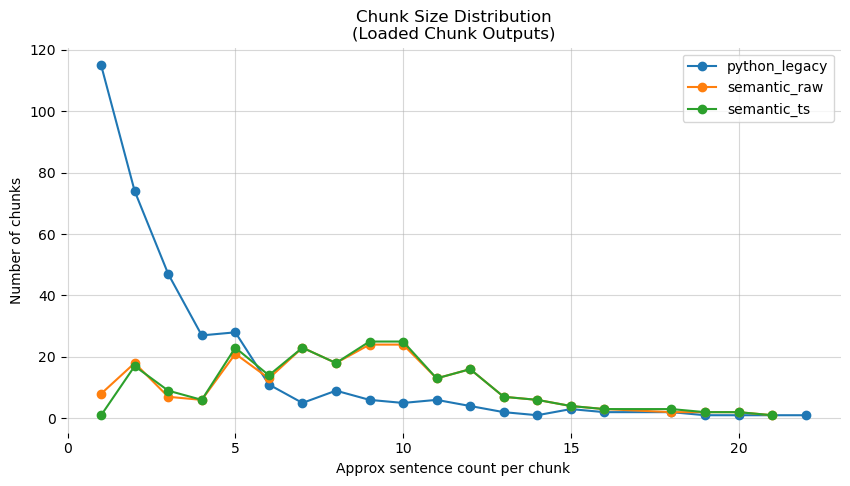

In [8]:
plot_frame = pd.concat(frames.values(), ignore_index=True)
plt.figure(figsize=(10, 5))
for source_name, group in plot_frame.groupby("source_name"):
    counts = group["sentenceCountApprox"].value_counts().sort_index()
    plt.plot(counts.index, counts.values, marker="o", label=source_name)

plt.xlabel("Approx sentence count per chunk")
plt.ylabel("Number of chunks")
plt.title("Chunk Size Distribution\n(Loaded Chunk Outputs)")
plt.legend()
plt.grid(alpha=0.5)
for spine in plt.gca().spines.values():
    spine.set_visible(False)
plt.show()

In [9]:
# Legacy reference only: useful for chunk-shape context, not for recall pass/fail.
if 'semantic_ts' not in frames or 'python_legacy' not in frames:
    raise FileNotFoundError('Need both semantic_ts and python_legacy loaded before running legacy comparison')

semantic_sentences = collect_sentence_set(frames['semantic_ts'])
python_sentences = collect_sentence_set(frames['python_legacy'])
semantic_words = collect_word_set(frames['semantic_ts'])
python_words = collect_word_set(frames['python_legacy'])

legacy_coverage_summary = pd.DataFrame([
    {
        'metric': 'sentences',
        'semantic_count': len(semantic_sentences),
        'python_count': len(python_sentences),
        'missing_from_semantic': len(python_sentences - semantic_sentences),
        'extra_in_semantic': len(semantic_sentences - python_sentences),
        'semantic_overlap_pct': round(100 * len(semantic_sentences & python_sentences) / max(len(python_sentences), 1), 2),
    },
    {
        'metric': 'words',
        'semantic_count': len(semantic_words),
        'python_count': len(python_words),
        'missing_from_semantic': len(python_words - semantic_words),
        'extra_in_semantic': len(semantic_words - python_words),
        'semantic_overlap_pct': round(100 * len(semantic_words & python_words) / max(len(python_words), 1), 2),
    },
])
legacy_coverage_summary

,metric,semantic_count,python_count,missing_from_semantic,extra_in_semantic,semantic_overlap_pct
0,sentences,1381,1005,463,839,53.93
1,words,3387,2922,0,465,100.00
